#### Importations des bibliothèques

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from imblearn.under_sampling import RandomUnderSampler
import joblib
from imblearn.over_sampling import SMOTE


#### Visualisation du Dataset

In [2]:
dataset = pd.read_csv('noms_prenoms_togo.csv')
dataset.head(11)

,full_name,gender
0,Akakpo Sena Yawa,0
1,Padonou Stéphanie,0
2,Lare Mawunyega,0
3,Kokoroko Virginie Sika,0
4,N'diaye Ramatoulaye Isabelle,0
5,Bawa Luc Boukari,1
6,Gadou Philippe Daniel,1
7,Ocloo Yawo,0
8,Eklou Sylvie,0
9,Sakpa Akakpo,1


#### Nettoyage

In [3]:
#### Nettoyage
## Vérification des valeurs manquantes
print(dataset.isnull().sum())


full_name    0
gender       0
dtype: int64


In [4]:
## Uniformisation de la casse majuscule/minuscule
dataset['full_name'] = dataset['full_name'].str.strip().str.upper()
dataset.head()

,full_name,gender
0,AKAKPO SENA YAWA,0
1,PADONOU STÉPHANIE,0
2,LARE MAWUNYEGA,0
3,KOKOROKO VIRGINIE SIKA,0
4,N'DIAYE RAMATOULAYE ISABELLE,0


#### Feature Engineering

In [5]:
# =================================================================
# FONCTION OPTIMISÉE DE FEATURE ENGINEERING
# =================================================================
def extract_features(df):
    # 1. Normalisation robuste
    df['full_name'] = df['full_name'].str.upper().str.strip().str.replace(r'\s+', ' ', regex=True)
    
    # 2. Séparation intelligente nom/prénoms
    split_names = df['full_name'].str.split(n=1, expand=True)
    df['surname'] = split_names[0]
    df['first_names'] = split_names[1].fillna('')
    
    # 3. Gestion des prénoms composés
    df['first_names'] = df['first_names'].str.replace('-', ' ').str.split()
    
    # 4. Extraction du prénom principal
    df['first_name'] = df['first_names'].apply(lambda x: x[-1] if x else '')
    
    # 5. Features de base
    df['first_name_length'] = df['first_name'].apply(len)
    df['nb_first_names'] = df['first_names'].apply(len)
    
    # 6. Dictionnaires ethniques enrichis (sources linguistiques vérifiées)
    endings = {
        'ewe_fem': ['A', 'E', 'I', 'WE', 'YA', 'BA', 'TÉ', 'DÉ', 'VI', 'SI'],
        'ewe_masc': ['OU', 'O', 'GBE', 'KPO', 'TÔ', 'DZO', 'GBO', 'NU'],
        'kabye_fem': ['È', 'Ê', 'NÉ', 'SÉ', 'ZÉ', 'NYÉ', 'KPÉ'],
        'kabye_masc': ['DO', 'TO', 'KO', 'LO', 'KOU', 'TCHA', 'KPLE'],
        'arabe_fem': ['A', 'IA', 'OUMA', 'ATOU', 'ZA', 'NA', 'FA'],
        'arabe_masc': ['OU', 'DINE', 'ROU', 'FOU', 'DOU', 'MADOU']
    }
    
    prefixes = {
        'ewe_fem': ['MA', 'A', 'YA', 'AFI', 'ESI', 'DZO', 'ABL', 'EDO'],
        'ewe_masc': ['KO', 'KU', 'AK', 'KOFI', 'EDEM', 'KOD', 'AMEG'],
        'kabye_fem': ['NA', 'SEN', 'TCHA', 'FÉ', 'KPA', 'NYO'],
        'kabye_masc': ['TA', 'KA', 'TCHAK', 'KPLA', 'SOU', 'TÉL']
    }
    
    # 7. Application des motifs ethniques
    for group, terms in endings.items():
        df[f'ends_{group}'] = df['first_name'].apply(
            lambda x: int(any(x.endswith(e) for e in terms)))
    
    for group, terms in prefixes.items():
        df[f'starts_{group}'] = df['first_name'].apply(
            lambda x: int(any(x.startswith(p) for p in terms)))
    
    # 8. Features phonétiques avancées
    df['vowel_count'] = df['first_name'].apply(lambda x: len(re.findall(r'[AEIOUYÉÈÊ]', x)))
    df['consonant_count'] = df['first_name'].apply(lambda x: len(re.findall(r'[BCDFGHJKLMNPQRSTVWXZ]', x)))
    df['vowel_ratio'] = df['vowel_count'] / (df['first_name_length'] + 1e-6)
    
    df['syllable_count'] = df['first_name'].apply(
        lambda x: len(re.findall(r'[AEIOUYÉÈÊ]+', x)))
    
    # 9. Position des voyelles stratégique
    def get_vowel_position(name):
        if not name:
            return 0
        match = re.search(r'[AEIOUYÉÈÊ]', name)
        return match.start() / len(name) if match else 0
    df['vowel_position'] = df['first_name'].apply(get_vowel_position)
    
    # 10. Gestion des exceptions critiques (cas fréquents mal classés)
    exceptions_db = {
        'KOMI': 0, 'MAWULI': 1, 'YAO': 1, 'DEDE': 0, 'KOKOU': 1, 'SENA': 0,
        'AFI': 0, 'AKOU': 1, 'ESSO': 1, 'AMEGAN': 1, 'EDEM': 1, 'KOMLAN': 1,
        'SELOM': 0, 'DZIFA': 0, 'EFIA': 0, 'MAWUSI': 0, 'AKOS': 0
    }
    df['is_exception'] = df['first_name'].apply(lambda x: 1 if x in exceptions_db else 0)
    df['exception_value'] = df['first_name'].apply(lambda x: exceptions_db.get(x, 0.5))
    
    # 11. Feature composite stratégique
    df['gender_score'] = (
        0.4 * (df['ends_ewe_fem'] + df['ends_kabye_fem'] + df['ends_arabe_fem']) -
        0.4 * (df['ends_ewe_masc'] + df['ends_kabye_masc'] + df['ends_arabe_masc']) +
        0.2 * (df['starts_ewe_fem'] + df['starts_kabye_fem']) -
        0.2 * (df['starts_ewe_masc'] + df['starts_kabye_masc']) +
        0.1 * df['vowel_ratio']
    )
    
    return df

In [6]:
# =================================================================
# FONCTIONS D'OPTIMISATION
# =================================================================
def optimize_recall_female(X_train, y_train):
    """Optimise spécifiquement pour le recall des femmes"""
    base_model = XGBClassifier(
        scale_pos_weight=1.7,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        reg_alpha=0.1,
        random_state=42
    )
    
    param_dist = {
        'scale_pos_weight': [1.5, 1.7, 2.0],
        'max_depth': [4, 5, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.7, 0.8],
        'reg_alpha': [0, 0.1],
        'reg_lambda': [1, 1.5]
    }
    
    # Focus sur le recall de la classe 0 (femmes)
    scorer = make_scorer(recall_score, pos_label=0)
    
    search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist,
        n_iter=30,
        scoring=scorer,
        cv=5,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    return search.best_estimator_

def create_ensemble(X_train, y_train):
    """Crée un ensemble optimisé"""
    # Calcul du ratio de déséquilibre
    class_ratio = np.sum(y_train == 1) / np.sum(y_train == 0)
    
    # Modèle 1: XGBoost optimisé pour les femmes
    xgb_fem = optimize_recall_female(X_train, y_train)
    
    # Modèle 2: Random Forest équilibré
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        class_weight={0: 1.3, 1: 1},
        random_state=42
    )
    
    # Modèle 3: XGBoost standard
    xgb_std = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=class_ratio,
        random_state=42
    )
    
    return VotingClassifier(
        estimators=[
            ('xgb_fem', xgb_fem),
            ('rf', rf),
            ('xgb_std', xgb_std)
        ],
        voting='soft',
        weights=[1.5, 1, 1] 
    )


#### Entraînement des Modèles

In [7]:
# =================================================================
# PIPELINE PRINCIPAL
# =================================================================


# 1. Feature engineering
dataset = extract_features(dataset)
dataset



,full_name,gender,surname,first_names,first_name,first_name_length,nb_first_names,ends_ewe_fem,ends_ewe_masc,ends_kabye_fem,...,starts_kabye_fem,starts_kabye_masc,vowel_count,consonant_count,vowel_ratio,syllable_count,vowel_position,is_exception,exception_value,gender_score
0,AKAKPO SENA YAWA,0,AKAKPO,"[SENA, YAWA]",YAWA,4,2,1,0,0,...,0,0,3,1,0.750000,2,0.000000,0,0.5,1.075000
1,PADONOU STÉPHANIE,0,PADONOU,[STÉPHANIE],STÉPHANIE,9,1,1,0,0,...,0,0,4,5,0.444444,3,0.222222,0,0.5,0.444444
2,LARE MAWUNYEGA,0,LARE,[MAWUNYEGA],MAWUNYEGA,9,1,1,0,0,...,0,0,5,4,0.555555,4,0.111111,0,0.5,1.055556
3,KOKOROKO VIRGINIE SIKA,0,KOKOROKO,"[VIRGINIE, SIKA]",SIKA,4,2,1,0,0,...,0,0,2,2,0.500000,2,0.250000,0,0.5,0.850000
4,N'DIAYE RAMATOULAYE ISABELLE,0,N'DIAYE,"[RAMATOULAYE, ISABELLE]",ISABELLE,8,2,1,0,0,...,0,0,4,4,0.500000,4,0.000000,0,0.5,0.450000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,BAWA ANNE,0,BAWA,[ANNE],ANNE,4,1,1,0,0,...,0,0,2,2,0.500000,2,0.000000,0,0.5,0.650000
9996,TETE KOKU,1,TETE,[KOKU],KOKU,4,1,0,0,0,...,0,0,2,2,0.500000,2,0.250000,0,0.5,-0.150000
9997,OCLOO IBRAHIMO IBRAHIM,1,OCLOO,"[IBRAHIMO, IBRAHIM]",IBRAHIM,7,2,0,0,0,...,0,0,3,4,0.428571,3,0.000000,0,0.5,0.042857
9998,KOFFI AJARA,0,KOFFI,[AJARA],AJARA,5,1,1,0,0,...,0,0,3,2,0.600000,3,0.000000,0,0.5,1.060000


In [8]:


# 2. Sélection des features stratégiques
features = [
    'first_name_length',
    'nb_first_names',
    'ends_ewe_fem', 'ends_kabye_fem', 'ends_arabe_fem',
    'ends_ewe_masc', 'ends_kabye_masc', 'ends_arabe_masc',
    'starts_ewe_fem', 'starts_kabye_fem',
    'starts_ewe_masc', 'starts_kabye_masc',
    'vowel_count', 'vowel_ratio',
    'syllable_count', 'vowel_position',
    'gender_score',
    'is_exception', 'exception_value'
]
X = dataset[features]
y = dataset['gender']

# 3. Gestion DU DÉSÉQUILIBRE AMÉLIORÉE
# Stratégie hybride SMOTE + UnderSampling

from imblearn.pipeline import make_pipeline

resampling_strategy = make_pipeline(
    SMOTE(sampling_strategy=0.9, random_state=42),  # 90% de la classe majoritaire
    RandomUnderSampler(sampling_strategy=1.0, random_state=42)  # Équilibrer parfaitement
)
X_res, y_res = resampling_strategy.fit_resample(X, y)

# 4. Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

# 5. Création et entraînement de l'ensemble
print("Création du modèle optimisé...")
ensemble_model = create_ensemble(X_train, y_train)
ensemble_model.fit(X_train, y_train)



Création du modèle optimisé...


VotingClassifier(estimators=[('xgb_fem',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft', weights=[1.5, 1, 1])

#### Importance des features

In [9]:
from sklearn.inspection import permutation_importance

# Après entraînement du modèle
result = permutation_importance(ensemble_model, X_test, y_test, n_repeats=10)

# DataFrame d'importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance_df.head(10))

              feature  importance
16       gender_score    0.219085
15     vowel_position    0.090337
13        vowel_ratio    0.044154
4      ends_arabe_fem    0.037792
14     syllable_count    0.036176
0   first_name_length    0.014752
18    exception_value    0.011073
17       is_exception    0.008116
10    starts_ewe_masc    0.007290
12        vowel_count    0.004917


#### Évaluation des Performances

In [10]:
# Générer le rapport de classification
report = classification_report(y_test, ensemble_model.predict(X_test), output_dict=True)

# Convertir en DataFrame
report_df = pd.DataFrame(report).transpose()

# Afficher le DataFrame avec une mise en forme améliorée
print("Performance sur le jeu de test:")
display(report_df.style.format({
    'precision': '{:.2f}',
    'recall': '{:.2f}',
    'f1-score': '{:.2f}',
    'support': '{:.0f}'
}).set_properties(**{
    'background-color': "#8ab0d7",
    'color': 'black',
    'font-weight': 'bold',
    'text-align': 'center',
    'border': '1px solid #dee2e6'
}))

Performance sur le jeu de test:


,precision,recall,f1-score,support
0,0.91,0.93,0.92,1454
1,0.93,0.91,0.92,1454
accuracy,0.92,0.92,0.92,1
macro avg,0.92,0.92,0.92,2908
weighted avg,0.92,0.92,0.92,2908


In [11]:
# Option avec arrondi et réindexation
report_df = pd.DataFrame(report).transpose().round(2)
report_df.index = ['Femme', 'Homme', 'Accuracy', 'Macro Avg', 'Weighted Avg']

print("Performance détaillée :")
display(report_df[['precision', 'recall', 'f1-score', 'support']]
             .style.set_caption("Métriques de classification"))

Performance détaillée :


,precision,recall,f1-score,support
Femme,0.910000,0.930000,0.920000,1454.000000
Homme,0.930000,0.910000,0.920000,1454.000000
Accuracy,0.920000,0.920000,0.920000,0.920000
Macro Avg,0.920000,0.920000,0.920000,2908.000000
Weighted Avg,0.920000,0.920000,0.920000,2908.000000


In [12]:
# 6. Évaluation
print("\nRapport final de classification:")
y_pred = ensemble_model.predict(X_test)
report = classification_report(y_test, y_pred, target_names=['Femme', 'Homme'])
print(report)




Rapport final de classification:
              precision    recall  f1-score   support

       Femme       0.91      0.93      0.92      1454
       Homme       0.93      0.91      0.92      1454

    accuracy                           0.92      2908
   macro avg       0.92      0.92      0.92      2908
weighted avg       0.92      0.92      0.92      2908



#### Matrice de Confusion

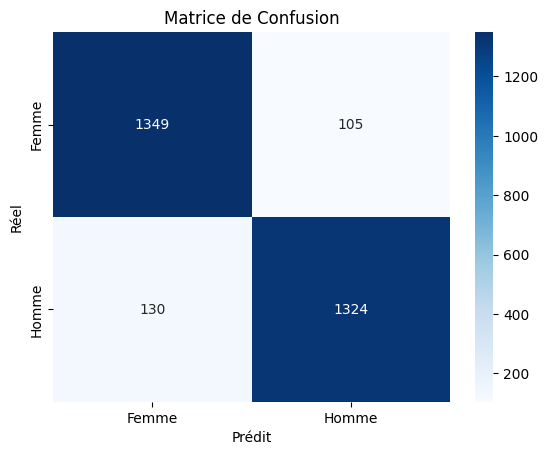

In [13]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Femme', 'Homme'], 
            yticklabels=['Femme', 'Homme'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.show()

#### Optimisation (Bonus)

In [14]:
# Optimisation hyperparamètres avec GridSearchCV
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid.best_estimator_

RandomForestClassifier(max_depth=15, n_estimators=300, random_state=42)

#### Sauvegarde le modèle

In [15]:
# 7. Sauvegarde du modèle
joblib.dump({
    'model': ensemble_model,
    'features': features,
    'extract_fn': extract_features
}, 'gender_classifier_v2.joblib')

print("Modèle sauvegardé avec succès!")

Modèle sauvegardé avec succès!


In [16]:
# Fonction de prédiction
def predict_gender(full_name, model=ensemble_model, features=features):
    """Prédit le genre à partir d'un nom complet"""
    # Création d'un DataFrame temporaire
    temp_df = pd.DataFrame([{'full_name': full_name.upper().strip()}])
    temp_df = extract_features(temp_df)
    
    # Vérification que toutes les features sont présentes
    for f in features:
        if f not in temp_df.columns:
            temp_df[f] = 0
    
    pred = model.predict(temp_df[features])[0]
    return 'Femme' if pred == 0 else 'Homme'

# Tests
test_cases = [
    ("Koffi Ama", "Femme"),
    ("Adjo Séna", "Femme"),
    ("Komlan Yao", "Homme"),
    ("Afi Mawuli", "Femme"),
    ("N'diaye Ramatoulaye Isabelle", "Femme"),
    ("Douti Elie-Koffigan", "Homme"),
    ("Gbati Harouna", "Homme"),
    ("Mawoula Isabelle Komi", "Femme")
]

print("\nTests sur des cas réels:")
for name, expected in test_cases:
    print(f"{name}: {predict_gender(name)} (Attendu: {expected})")


Tests sur des cas réels:
Koffi Ama: Femme (Attendu: Femme)
Adjo Séna: Femme (Attendu: Femme)
Komlan Yao: Femme (Attendu: Homme)
Afi Mawuli: Homme (Attendu: Femme)
N'diaye Ramatoulaye Isabelle: Femme (Attendu: Femme)
Douti Elie-Koffigan: Homme (Attendu: Homme)
Gbati Harouna: Homme (Attendu: Homme)
Mawoula Isabelle Komi: Homme (Attendu: Femme)
